In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('titanic_data_updated.csv')

In [3]:
df.shape

print(f"Total potential features: {df.shape[1]}")
print(f"Total sample data : {df.shape[0]}")

Total potential features: 12
Total sample data : 891


In [4]:
# df.head(10)

df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
766,767,no,first,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C
131,132,no,third,"Coelho, Mr. Domingos Fernandeo",male,20.0,0,0,SOTON/O.Q. 3101307,7.0500,NaN,S
485,486,no,third,"Lefebre, Miss. Jeannie",female,NaN,3,1,4133,25.4667,NaN,S
701,702,yes,first,"Silverthorne, Mr. Spencer Victor",male,35.0,0,0,PC 17475,26.2875,E24,S
579,580,yes,third,"Jussila, Mr. Eiriik",male,32.0,0,0,STON/O 2. 3101286,7.9250,NaN,S
505,506,no,first,"Penasco y Castellana, Mr. Victor de Satode",male,18.0,1,0,PC 17758,108.9000,C65,C
808,809,no,second,"Meyer, Mr. August",male,39.0,0,0,248723,13.0000,NaN,S
874,875,yes,second,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
385,386,no,second,"Davies, Mr. Charles Henry",male,18.0,0,0,S.O.C. 14879,73.5000,NaN,S
733,734,no,second,"Berriman, Mr. William John",male,23.0,0,0,28425,13.0000,NaN,S


In [5]:
# missing 

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
# checking duplicates

df.duplicated().sum()

df.drop_duplicates(inplace = True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [8]:
# statistical value
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


<!-- Univariate analysis -->

 # Univariate Analysis (caegorical)

<Axes: xlabel='Survived', ylabel='count'>

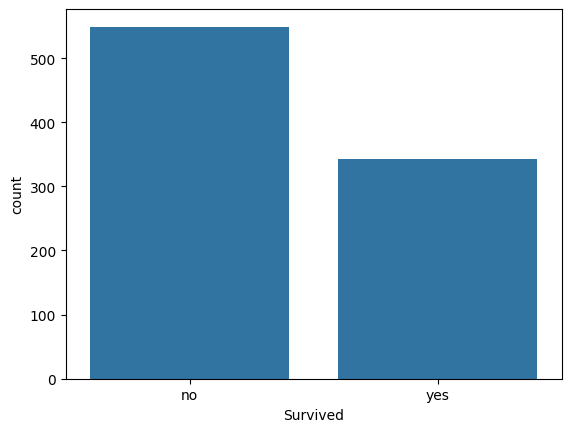

In [9]:
sns.countplot(data = df, x=df['Survived'])

In [10]:
df['Survived'].value_counts()

Survived
no     549
yes    342
Name: count, dtype: int64

In [11]:
# getting the percentage
(df['Survived'].value_counts() /len(df)) * 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

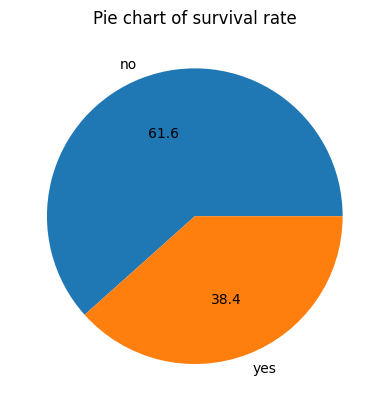

In [12]:
# seeing in piechart
survived_count = df['Survived'].value_counts()

survived_label = df['Survived'].unique() 

plt.pie(survived_count, autopct="%1.1f", labels=survived_label)
plt.title('Pie chart of survival rate')
plt.show()

<Axes: xlabel='Pclass', ylabel='count'>

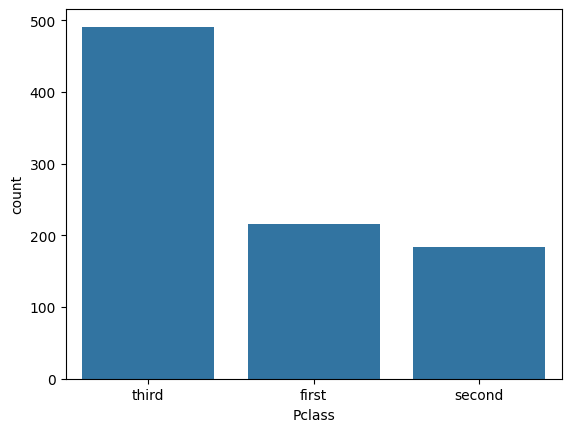

In [13]:
sns.countplot(data = df, x=df['Pclass'])

In [14]:
(df['Pclass'].value_counts() /len(df)) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

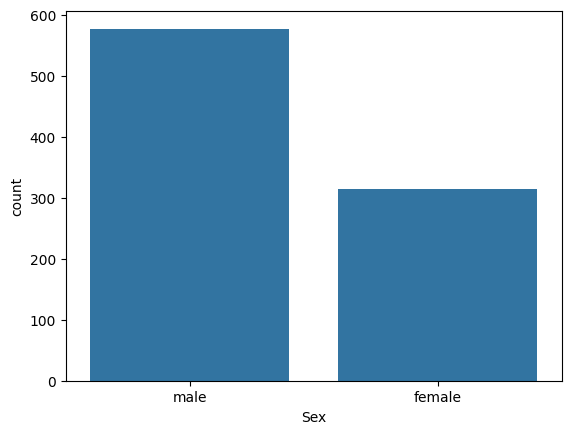

In [15]:
sns.countplot(data = df, x=df['Sex'])

In [16]:
(df['Sex'].value_counts() /len(df)) * 100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

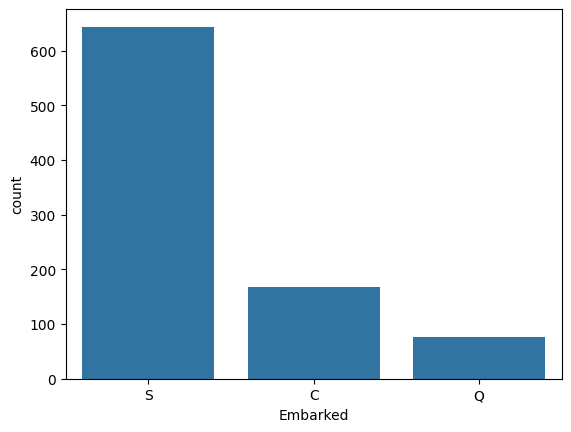

In [17]:
sns.countplot(data= df, x=df['Embarked'])

In [18]:
(df['Embarked'].value_counts() /len(df)) * 100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

# Univariate Analysis ( Numerical Value )

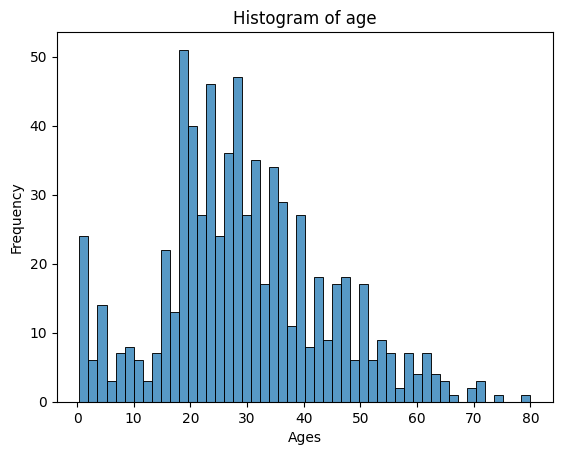

In [19]:
sns.histplot(df['Age'], bins=50)

plt.title('Histogram of age')
plt.xlabel('Ages')
plt.ylabel('Frequency')
plt.show()

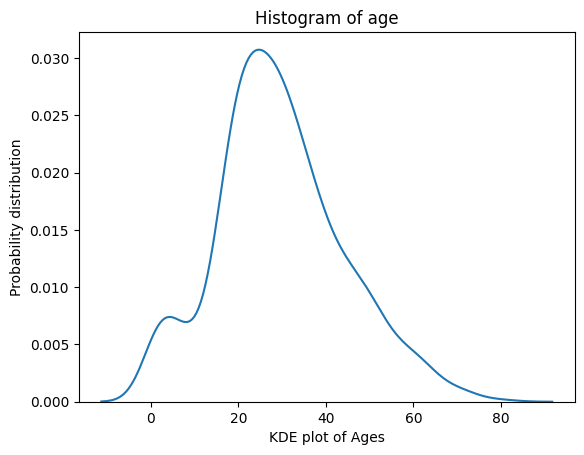

In [20]:
sns.kdeplot(df['Age'])

plt.title('Histogram of age')
plt.xlabel('KDE plot of Ages')
plt.ylabel('Probability distribution')
plt.show()

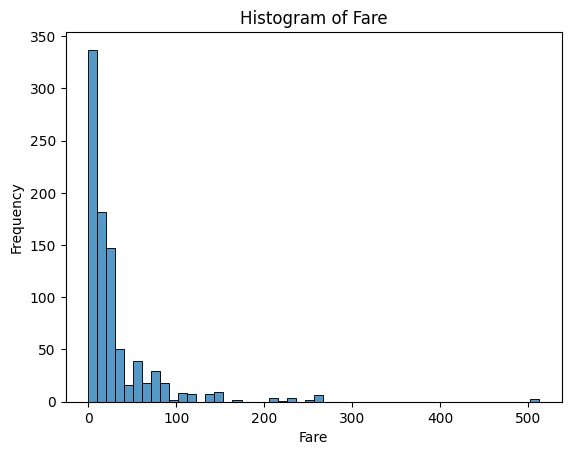

In [21]:
sns.histplot(df['Fare'], bins=50)

plt.title('Histogram of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

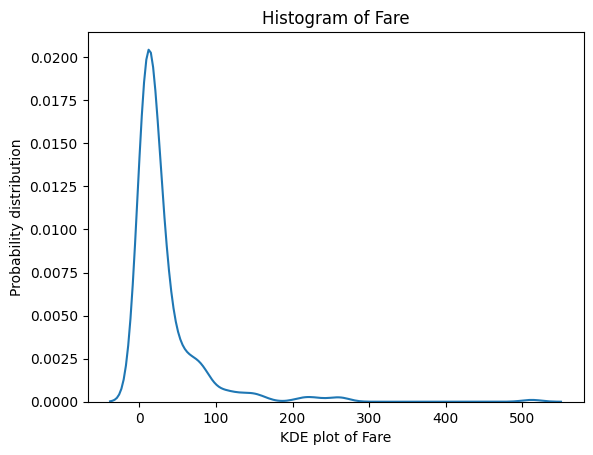

In [22]:
sns.kdeplot(df['Fare'])

plt.title('Histogram of Fare')
plt.xlabel('KDE plot of Fare')
plt.ylabel('Probability distribution')
plt.show()

<Axes: ylabel='Fare'>

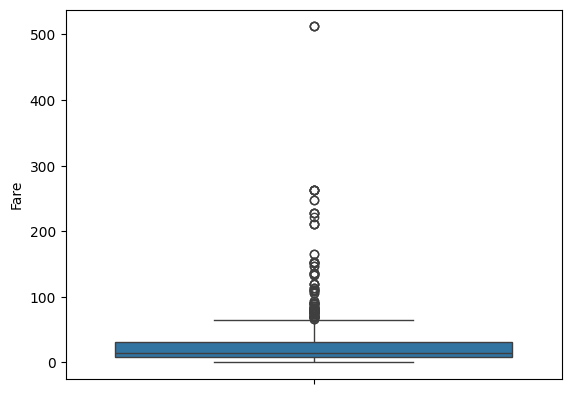

In [23]:
sns.boxplot(df['Fare'])

# Mult variate analysis

<Axes: xlabel='Sex', ylabel='count'>

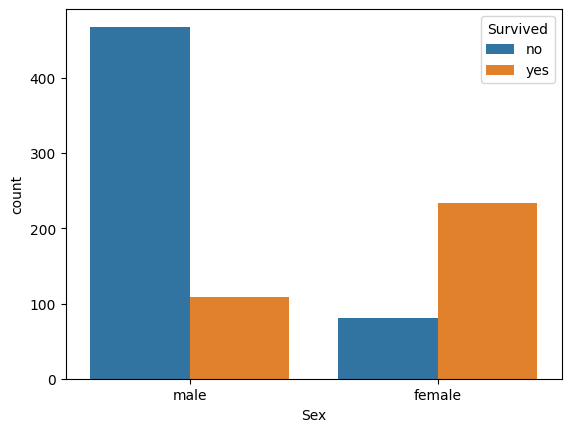

In [24]:
sns.countplot(x=df['Sex'], hue=df['Survived'])

In [25]:
gender_split = df.groupby('Sex')['Survived'].value_counts(normalize=True)  

print(gender_split)

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

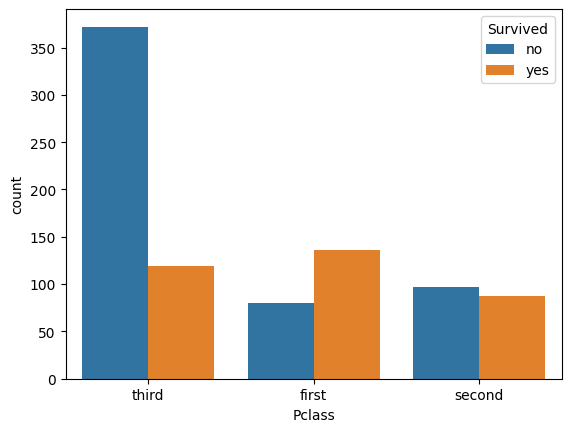

In [26]:
sns.countplot(x=df['Pclass'], hue=df['Survived'])

In [27]:
pclass_split = df.groupby('Pclass')['Survived'].value_counts(normalize=True)  

print(pclass_split)

Pclass  Survived
first   yes         0.629630
        no          0.370370
second  no          0.527174
        yes         0.472826
third   no          0.757637
        yes         0.242363
Name: proportion, dtype: float64


<Axes: xlabel='Pclass', ylabel='Fare'>

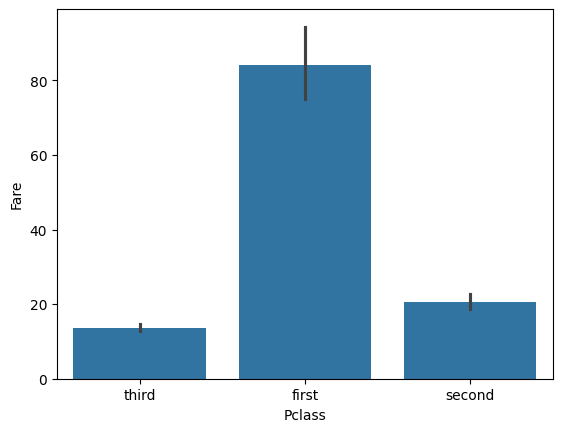

In [28]:
sns.barplot(x=df['Pclass'],y=df['Fare'])

<Axes: xlabel='Survived', ylabel='Age'>

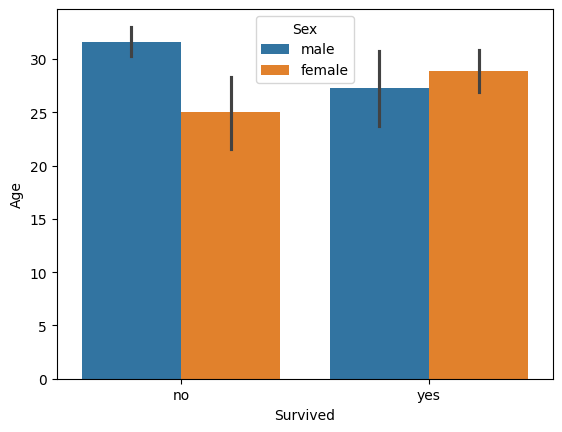

In [29]:
sns.barplot(x=df['Survived'],y=df['Age'],hue=df['Sex'])

# Density Graph

<Axes: xlabel='Age', ylabel='Density'>

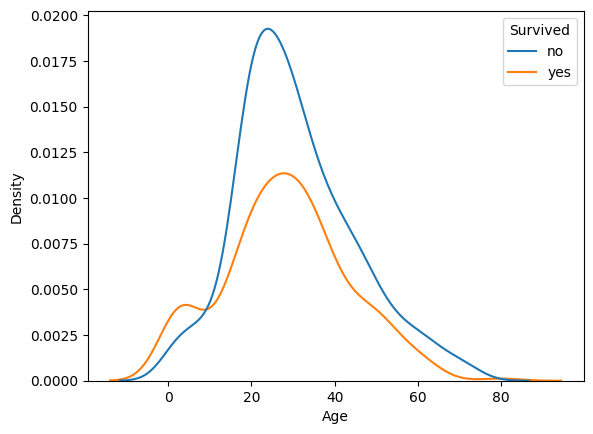

In [30]:
sns.kdeplot(data=df, x='Age',hue='Survived')

In [31]:
df = sns.load_dataset('tips')

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

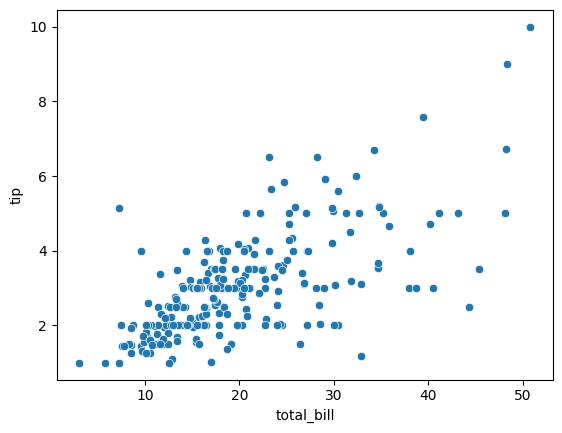

In [32]:
sns.scatterplot(data=df, x='total_bill', y='tip')

<Axes: xlabel='total_bill', ylabel='tip'>

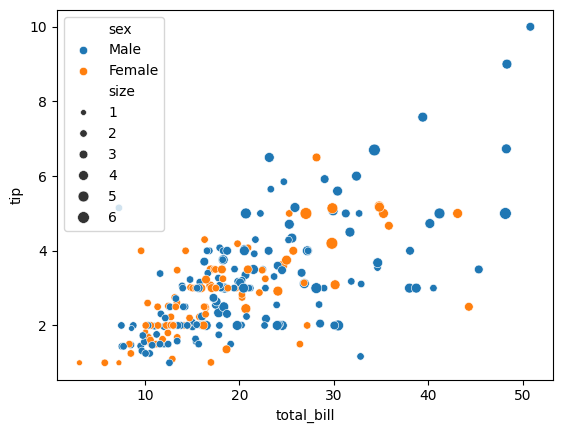

In [33]:
sns.scatterplot(
    data=df,
    x='total_bill',
    y='tip' , 
    hue='sex',
    size='size'
    )

In [37]:
from ydata_profiling import ProfileReport

df = pd.read_csv('titanic_data_updated.csv')

profile = ProfileReport(df, title='Titanic Profile Report')

profile.to_file("my_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 37.17it/s]
